## Problem 2: Generating PRN Code Replicas [8 points]

**Goal of this problem**: The GPS signal is overlayed with binary code sequences called Gold codes. In this problem, you will implement the algorithm to create the Gold codes used for every GPS satellite's GPS L1 C/A signal.

First, read these excerpts from Misra and Enge. If you have a physical textbook, these are on pages 62 and 63 at the end of Chapter 2.

<figure>
  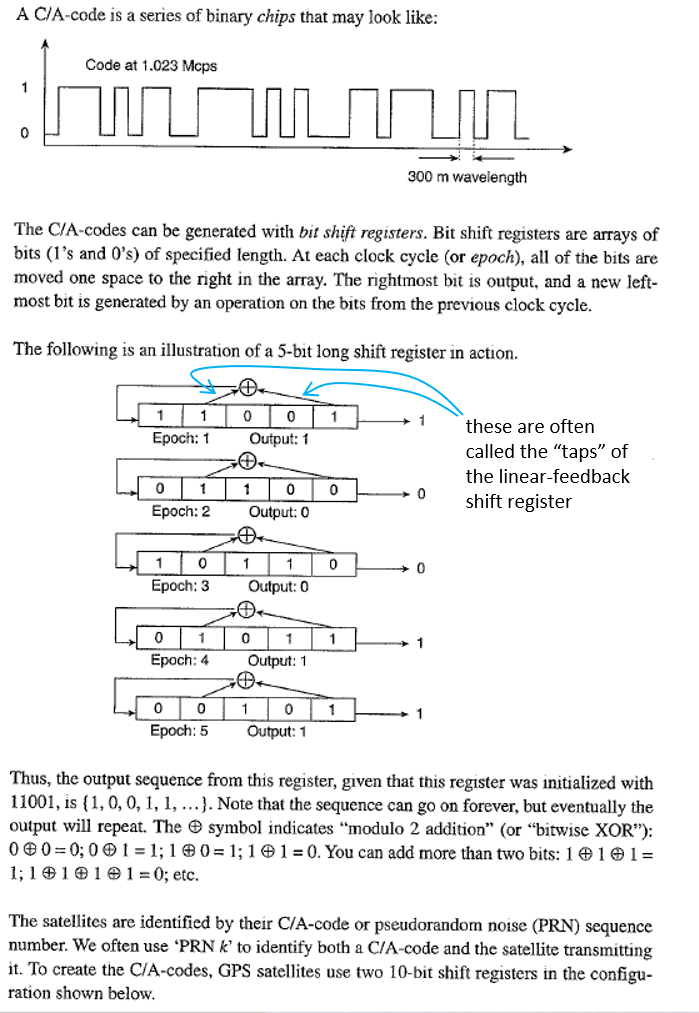
  <figcaption>Misra and Enge excerpt on binary codes and bit shift registers.</figcaption>
</figure>

<figure>
  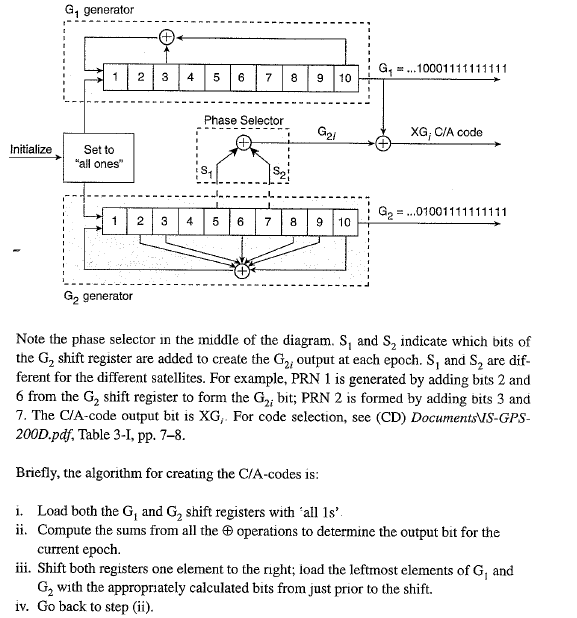
  <figcaption>Misra and Enge excerpt on generating the Gold codes for GPS. Note the "phase selector" block will change for different GPS PRNs.</figcaption>
</figure>


If you look back to problem 2 on homework 1 or problem 3 on homework 2, GPS PRN 10, 28, and 32 are all visible in the sky. So, we will be focusing on these three satellites for this and the next problem to add a bit of realism.

### 2.1 PRN Sequence [4 points]

Create the entire 1023-chip C/A code for PRN 10. To get the phase selector indices for a particular PRN, you can refer to the most recent GPS Interface Specification (IS-GPS-200 on https://www.navcen.uscg.gov/gps-technical-references) and take a look at the table of Code Phase Assignments **for the C/A signal**.

Report and plot the code's first 16 and last 16 chips in 2 separate plots. Use a stepwise or "staircase" plotting style (e.g., `plt.step` in Python's `matplotlib`), so the signal looks like a binary, switching signal between 0 and 1. Also, ensure that your 2 plots are labeled or titled (to distinguish them), ensure your axes are labeled, and include grid lines.

**Hints:**

a. The GPS Interface Specification also has the first 10 chips expressed in octal notation (see this [conversion table](https://www.ibm.com/docs/en/aix/7.2?topic=adapters-ascii-decimal-hexadecimal-octal-binary-conversion-table) from IBM) so you can check your implementation! For PRN 15, the first ten chips expressed in octal notation are `1131` (the leading digit (1) just represents a "1" for the very first chip, and the last 3 digits correspond to the remaining 9 chips).

b. A simple way to model a shift register in code is with a 10-bit array, e.g., `G = np.concatenate(([new_bit], G[0:9]))` (using 0-indexing).

c. For the sake of this problem and the next problem, you may find it helpful to have a single function whereby you pass the phase selectors for the PRN and the number of chips to generate as input. The function should output the code replica for that satellite up to the number of selected chips.

d. If you want to avoid using XOR operations, you can do the following transformations: (binary 0 → +1) and (binary 1 → -1). Then an XOR operation is equivalent to simple multiplication!
$$
\begin{aligned}
0 \oplus 0 = 0 \quad &\to \quad +1 \cdot +1 = +1, \\
0 \oplus 1 = 1 \quad &\to \quad +1 \cdot -1 = -1, \\
1 \oplus 0 = 1 \quad &\to \quad -1 \cdot +1 = -1, \\
1 \oplus 1 = 0 \quad &\to \quad -1 \cdot -1 = +1.
\end{aligned}
$$
Just be careful that you *convert back* correctly to binary values when plotting and reporting your chips. And, do not forget to also transform your initialization, correspondingly. *Note*: It is important that a binary 1 is converted to -1 (*not* +1); otherwise this trick will not work.

***ANSWER***

[Report and plot the code's first 16 and last 16 chips in 2 separate plots. Include your code.]

In [26]:
import numpy as np  # Array manipulation
import matplotlib.pyplot as plt  # Plotting


def create_prn(idx1: int, idx2: int, length: int) -> np.ndarray:
    """Generates a Pseudo-Random Noise (PRN) code using Gold code sequences.

    This function simulates the generation of a PRN code, commonly used in
    systems like GPS. It employs two linear-feedback shift registers (LFSRs),
    G1 and G2, with specific feedback polynomials. The final PRN sequence is
    the exclusive OR (XOR) of the G1 output and a phase-selected G2 output.
    The phase is determined by the `idx1` and `idx2` tap selections from the
    G2 register.

    Args:
        idx1 (int): The index of the first tap for the G2 register output.
        idx2 (int): The index of the second tap for the G2 register output.
        length (int): The desired length of the PRN sequence.

    Returns:
        np.ndarray: A NumPy array of integers (0s and 1s) representing the
                    generated PRN sequence.
    """

    prn_code = []

    """ G = push(G,1) """
    push = lambda G,bit: np.concatenate(([bit], G[0:9]))

    G1 = np.array([1] * 10)
    G2 = np.array([1] * 10)

    for i in range(length):

      next_1 = G1[2] ^ G1[9]
      next_2 = G2[1] ^ G2[2] ^ G2[5] ^ G2[7] ^ G2[8] ^ G2[9]

      shift_val = G2[idx1 - 1] ^ G2[idx2 - 1]

      output = G1[9] ^ shift_val
      prn_code.append(output)

      G1 = push(G1, next_1)
      G2 = push(G2, next_2)

    return np.array(prn_code)

In [27]:
  # Code phase selection:
  #   C/A = 2 x 3
  #   X2 = 10
  # Code delay chips:
  #   C/A = 251
  #   P = 10
  # First 10 chips Octal:
  #   C/A = 1504 -> 1101000100

create_prn(2,3,10)

# Works!

array([1, 1, 0, 1, 0, 0, 0, 1, 0, 0])

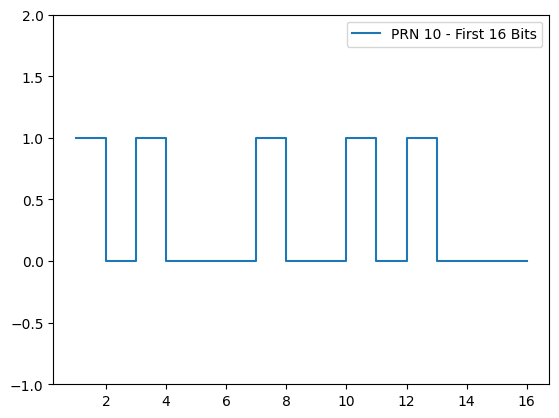

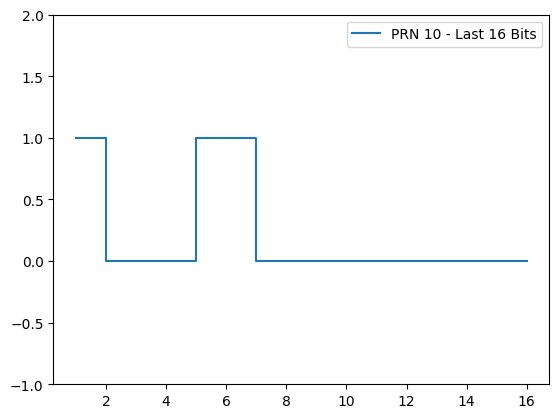

P2.1
First 16 bits: [1 1 0 1 0 0 0 1 0 0 1 0 1 0 0 0]
Last 16 bits:  [1 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0]


In [28]:
prn_code_sat1 = create_prn(2,3,1023)
first_16_bits = prn_code_sat1[:16]
last_16_bits = prn_code_sat1[-16:]

plt.step(np.arange(1,17), first_16_bits)
plt.ylim(-1,2)
plt.legend(["PRN 10 - First 16 Bits"])
plt.show()

plt.step(np.arange(1,17), last_16_bits)
plt.ylim(-1,2)
plt.legend(["PRN 10 - Last 16 Bits"])
plt.show()

# *** DO NOT MODIFY THE CODE BELOW ***
print("P2.1")
print("First 16 bits:", first_16_bits)
print("Last 16 bits: ", last_16_bits)

### 2.2 Periodic Sequence [2 points]

Create the C/A code output for PRN 10 **from epochs 1024 to 2046** as a 1023-element vector. Report and plot the first 16 and last 16 chips of this vector. How does this code compare with the one you generated in 2.1?

**Hint:** Be careful with indexing errors when creating the code if using 0-indexing.

***ANSWER***

[Report and plot the code's first 16 and last 16 chips in 2 separate plots. Include your code.]

1023


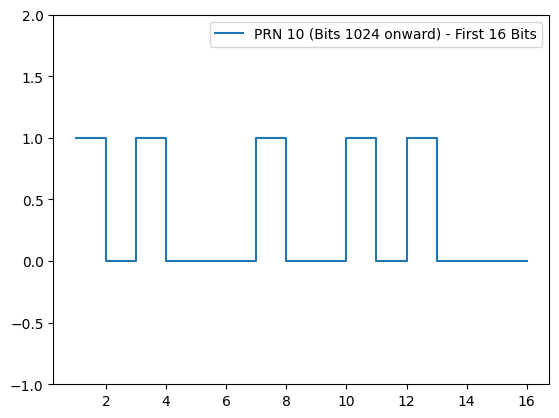

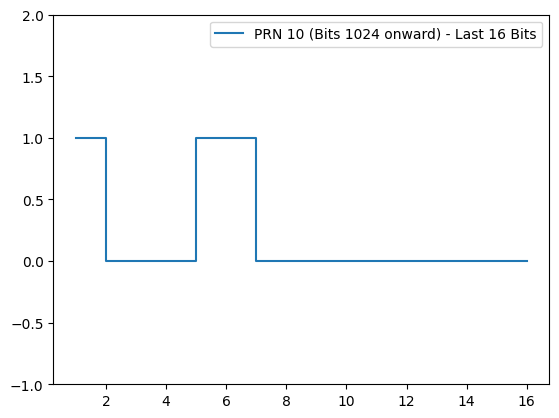

P2.2
First 16 bits: [1 1 0 1 0 0 0 1 0 0 1 0 1 0 0 0]
Last 16 bits:  [1 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0]


In [29]:
prn_code_sat1_2046 = create_prn(2,3,2046)[1023:]
print(len(prn_code_sat1_2046))
first_16_bits = prn_code_sat1_2046[:16]
last_16_bits = prn_code_sat1_2046[-16:]

plt.step(np.arange(1,17), first_16_bits)
plt.ylim(-1,2)
plt.legend(["PRN 10 (Bits 1024 onward) - First 16 Bits"])
plt.show()

plt.step(np.arange(1,17), last_16_bits)
plt.ylim(-1,2)
plt.legend(["PRN 10 (Bits 1024 onward) - Last 16 Bits"])
plt.show()
# *** DO NOT MODIFY THE CODE BELOW ***
print("P2.2")
print("First 16 bits:", first_16_bits)
print("Last 16 bits: ", last_16_bits)

### 2.3 A Different PRN [1 point]

Repeat 2.1 for PRN 28.

**Hint:** You can check the first 10 Chips Octal values in the GPS Interface Specification.

[Report and plot the code's first 16 and last 16 chips in 2 separate plots. Include your code.]

[1 1 1 1 1 1 1 1 0 0]


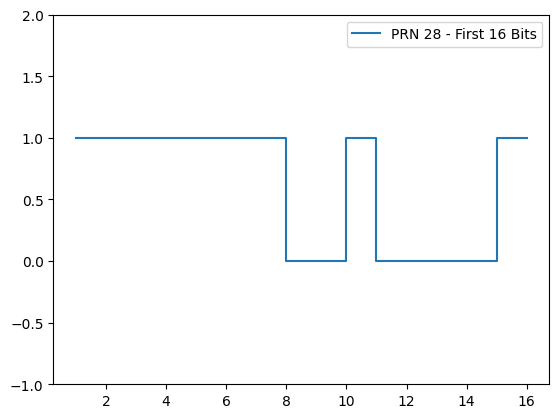

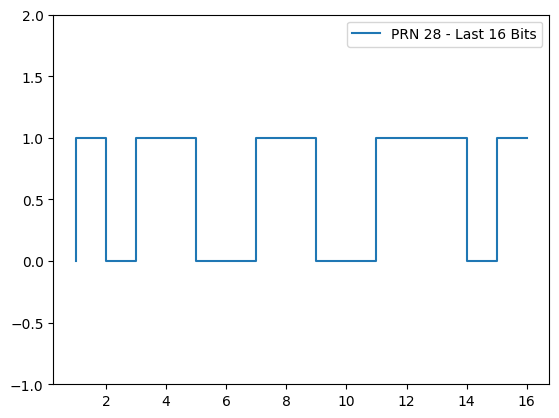

P2.3
First 16 bits: [1 1 1 1 1 1 1 1 0 0 1 0 0 0 0 1]
Last 16 bits:  [0 1 0 1 1 0 0 1 1 0 0 1 1 1 0 1]


In [30]:
print(create_prn(8,10,10)) # Same as 1111111100 (yay)
prn_code_sat2 = create_prn(8,10,1023)
first_16_bits = prn_code_sat2[:16]
last_16_bits = prn_code_sat2[-16:]

plt.step(np.arange(1,17), first_16_bits)
plt.ylim(-1,2)
plt.legend(["PRN 28 - First 16 Bits"])
plt.show()

plt.step(np.arange(1,17), last_16_bits)
plt.ylim(-1,2)
plt.legend(["PRN 28 - Last 16 Bits"])
plt.show()

# *** DO NOT MODIFY THE CODE BELOW ***
print("P2.3")
print("First 16 bits:", first_16_bits)
print("Last 16 bits: ", last_16_bits)

### 2.4 A Third PRN [1 point]

Repeat 2.1 for PRN 32.

**Hint:** You can check the first 10 Chips Octal values in the GPS Interface Specification.

[Report and plot the code's first 16 and last 16 chips in 2 separate plots. Include your code.]

[1 1 1 1 0 0 1 0 1 0]


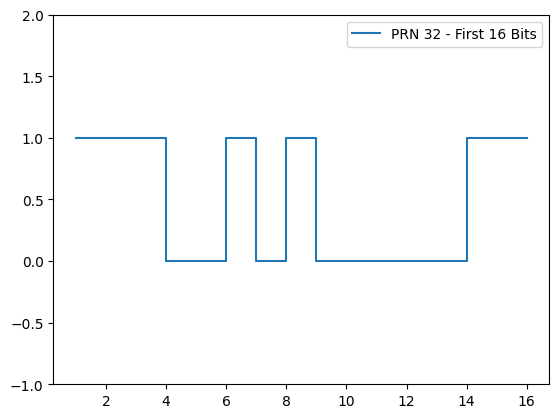

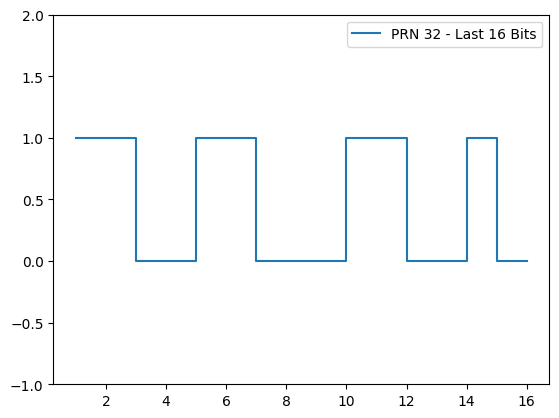

P2.4
First 16 bits: [1 1 1 1 0 0 1 0 1 0 0 0 0 0 1 1]
Last 16 bits:  [1 1 1 0 0 1 1 0 0 0 1 1 0 0 1 0]


In [31]:
print(create_prn(4,9,10)) # Same as 1111001010 (yay)
prn_code_sat3 = create_prn(4,9,1023)
first_16_bits = prn_code_sat3[:16]
last_16_bits = prn_code_sat3[-16:]

plt.step(np.arange(1,17), first_16_bits)
plt.ylim(-1,2)
plt.legend(["PRN 32 - First 16 Bits"])
plt.show()

plt.step(np.arange(1,17), last_16_bits)
plt.ylim(-1,2)
plt.legend(["PRN 32 - Last 16 Bits"])
plt.show()


# *** DO NOT MODIFY THE CODE BELOW ***
print("P2.4")
print("First 16 bits:", first_16_bits)
print("Last 16 bits: ", last_16_bits)

## Problem 3: CDMA & Correlation [16 points + 1 bonus]

**Goal of this problem**: In the first week of class, we briefly talked about how we correlate the incoming signal from GPS with our local replica. With the powerful structure of the Code-Division Multiple Access (CDMA), we can correlate signals despite the very weak power of the GPS signals. This correlation process allows us to (1) detect if a particular satellite signal is present in our incoming signal and (2) evaluate our pseudorange measurement ($\rho^{(k)}$) with remarkable precision. In this problem, we will explore the power of correlation.

First, read the following excerpts from Misra and Enge. If you have a physical textbook, these are on page 64, at the end of Chapter 2.

<figure>
  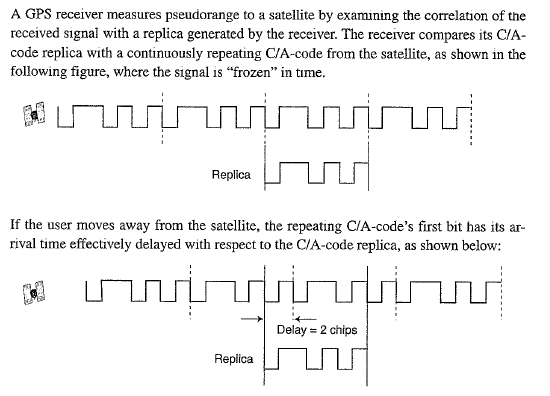
  <figcaption>Misra and Enge excerpt showing alignment of local replica with incoming signal.</figcaption>
</figure>

<figure>
  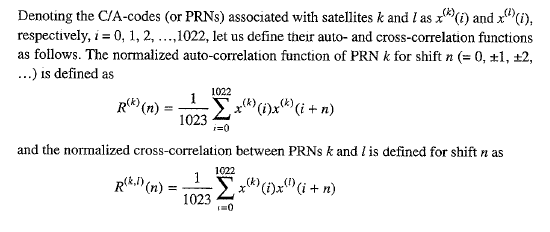
  <figcaption>Misra and Enge excerpt on auto and cross-correlation.</figcaption>
</figure>

For this problem, to perform the auto and cross-correlations, you will need to **convert the {0,1} binary sequences from problem 2 to {+1, -1} binary sequences**. (It is customary to transform $0 \to +1$ and $1 \to -1$, but it should not matter for this problem since we are only computing auto and cross-correlations.)
**For all plots, ensure that your axes are labeled and include grid lines**.

### 3.1 Autocorrelation [3 points]

Plot the normalized circular autocorrelation function of the code for PRN 10, i.e., $R^{(10)}(n)$. How many unique values of the autocorrelation function are there? What are these unique values?

*Hint:* Don't forget to normalize (i.e., account for the fraction out front of the sum).

*Side-note:* Gold codes are pretty special :)

*Hint:* The circular cross-correlation is defined as:
$$
r_{xy}[k] = \frac{1}{N} \sum_{n=0}^{N-1} x[n] \cdot y\left[ (n-k) \pmod N \right] \quad \text{for } k = 0, 1, \dots, N-1
$$

***ANSWER***

In [32]:
def correlate(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    f"""
    Computes the normalized circular cross-correlation of two 1D signals.

    This function assumes x and y are of the same length.

    Args:
        x (np.ndarray): The first input signal.
        y (np.ndarray): The second input signal.

    Returns:
        np.ndarray: The N-point circular cross-correlation of x and y.
    """
    r = np.array([np.sum([x[n] * y[(n-k)%len(x)] for n in range(len(x))]) for k in range(len(x))]) / (len(x)) # TODO
    return r
# print(correlate([1, 2], [3, 2]))

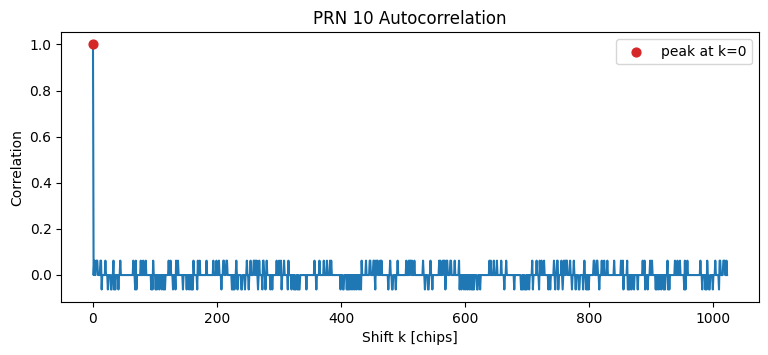

P3.1
Peak: 0
Number of unique values: 4
Unique values:   [-0.0635 -0.000978 0.0616 1]
Expected values: [-0.0635 -0.000978 0.0616 1]


In [33]:
prn = 2 * prn_code_sat1 - 1
r = correlate(prn, prn)

N = len(prn)
k = np.arange(0,N)

unique_values = np.unique(r)  # TODO
peak = int(np.argmax(r)) if r.max() > 0.5 else -1

# Expected values from book 9.5.2
n_exponent = np.log2(N + 1)
beta = 1 + 2**( np.floor((n_exponent+2)/2) )
expected_values = np.sort(np.round(
    np.array([1.0, -1.0/N, (beta-2)/N, -beta/N]),
    6
))

k = np.arange(N)
plt.figure(figsize=(9, 3.5))
plt.plot(k, r)
plt.scatter([peak], [r[peak]], s=40, color="tab:red", zorder=3, label=f"peak at k={peak}") # Peak
plt.title("PRN 10 Autocorrelation")
plt.xlabel("Shift k [chips]")
plt.ylabel("Correlation")
plt.legend(loc="best")
plt.show()



# *** DO NOT MODIFY THE CODE BELOW ***
print("P3.1")
print("Peak:", peak)
print("Number of unique values:", len(unique_values))
with np.printoptions(formatter={"float": lambda x: f"{x:0.3g}"}):
    print("Unique values:  ", unique_values)
    print("Expected values:", expected_values)

<!-- [Compute and plot the cross-correlation, provide its unique values and peak (if present), and explain whether the results are expected.] -->

This result aligns with expectations for the autocorrelation. That is, it makes sense that PRN 10 will have a strong autocorrelation with itself at 0 chips in offset because it is the same signal on to of itself.

### 3.2 Autocorrelation With Random Noise [2 points]

Create a truly random, length-1023 {+1, -1} binary sequence, where each element is +1 with probability 0.5 and -1 with probability 0.5. Plot its normalized autocorrelation function. How many *unique* values of the autocorrelation function are there?
    
*Hint:* Notice in the Misra and Enge excerpt that the example PRN signal is periodic (continuously repeats itself for all time). Assume this is also true for this truly random, length-1023 binary code sequence.

*Hint:* The number of unique values will change depending on the random code you generate, but it should be fairly different than 1.

*Hint:* For reproducibility, you can use a `seed` to initialize the randomness the same every time you restart the code.

***ANSWER***

[Compute and plot the cross-correlation, provide its unique values and peak (if present), and explain whether the results are expected.]

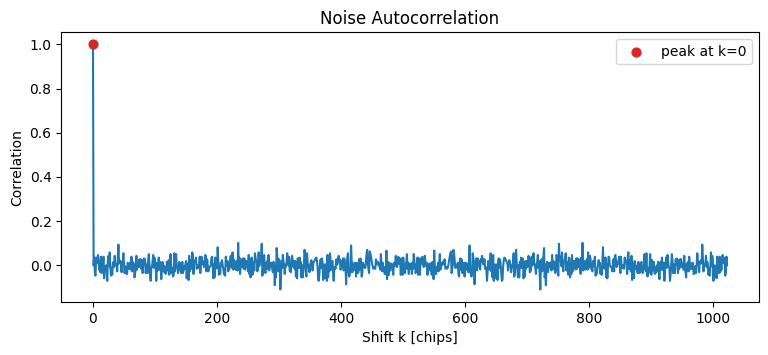

P3.2
Peak: 0
Number of unique values: 47
Unique values:   [-0.11 -0.0909 -0.087 -0.0714 -0.0674 -0.0635 -0.0596 -0.0557 -0.0518
 -0.0479 -0.044 -0.0401 -0.0362 -0.0323 -0.0283 -0.0244 -0.0205 -0.0166
 -0.0127 -0.0088 -0.00489 -0.000978 0.00293 0.00684 0.0108 0.0147 0.0186
 0.0225 0.0264 0.0303 0.0342 0.0381 0.042 0.0459 0.0499 0.0538 0.0577
 0.0616 0.0655 0.0694 0.0772 0.0811 0.089 0.0929 0.0968 0.101 1]


In [34]:
np.random.seed(0)
noise = np.random.choice([-1, 1], 1023)

r = correlate(noise, noise)
N = len(noise)
k = np.arange(0,N)

unique_values = np.unique(r)  # TODO
peak = int(np.argmax(r)) if r.max() > 0.5 else -1

k = np.arange(N)
plt.figure(figsize=(9, 3.5))
plt.plot(k, r)
plt.scatter([peak], [r[peak]], s=40, color="tab:red", zorder=3, label=f"peak at k={peak}") # Peak
plt.title("Noise Autocorrelation")
plt.xlabel("Shift k [chips]")
plt.ylabel("Correlation")
plt.legend(loc="best")
plt.show()

# *** DO NOT MODIFY THE CODE BELOW ***
print("P3.2")
print("Peak:", peak)
print("Number of unique values:", len(unique_values))
with np.printoptions(formatter={"float": lambda x: f"{x:0.3g}"}):
    print("Unique values:  ", unique_values)

This result also aligns with expectations for the autocorrelation. The autocorrelation function is designed to account for lots of noise. Even with noise that strongly surpasses the signal of the GPS, it still produces a highly unique peak at 0 chips offset.

### 3.3 Delayed Autocorrelation [2 points]

Let's see how we can find the chip offset between the received PRN and the replica PRN. Create a 1023-chip PRN sequence by **circularly** delaying PRN 10 by 300 chips. This delayed signal mimics our received PRN. Plot the normalized cyclic cross-correlation function of this delayed version with PRN 10 (our replica). Is the peak of the correlation where you had expected it to be? Explain why or why not.

*Hint:* You can exploit the periodic nature of the code sequence and make it cyclic by using a longer code sequence, as in Problem 2.2.

***ANSWER***

[Compute and plot the cross-correlation, provide its unique values and peak (if present), and explain whether the results are expected.]

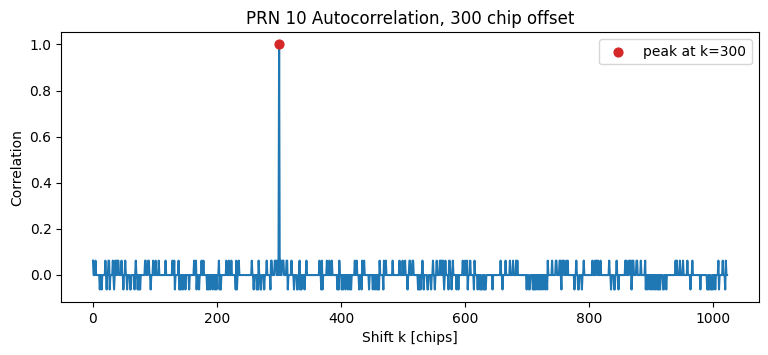

P3.3
Peak: 300
Number of unique values: 4
Unique values:   [-0.0635 -0.000978 0.0616 1]
Expected values: [-0.0635 -0.000978 0.0616 1]


In [35]:
shift = 300

prn = 2 * prn_code_sat1 - 1
prn_delayed = np.roll(prn, shift)
r = correlate(prn_delayed, prn)

N = len(prn)
k = np.arange(0,N)

unique_values = np.unique(r)  # TODO
peak = int(np.argmax(r)) if r.max() > 0.5 else -1

# Expected values from book 9.5.2
n_exponent = np.log2(N + 1)
beta = 1 + 2**( np.floor((n_exponent+2)/2) )
expected_values = np.sort(np.round(
    np.array([1.0, -1.0/N, (beta-2)/N, -beta/N]),
    6
))

k = np.arange(N)
plt.figure(figsize=(9, 3.5))
plt.plot(k, r)
plt.scatter([peak], [r[peak]], s=40, color="tab:red", zorder=3, label=f"peak at k={peak}") # Peak
plt.title("PRN 10 Autocorrelation, 300 chip offset")
plt.xlabel("Shift k [chips]")
plt.ylabel("Correlation")
plt.legend(loc="best")
plt.show()

# *** DO NOT MODIFY THE CODE BELOW ***
print("P3.3")
print("Peak:", peak)
print("Number of unique values:", len(unique_values))
with np.printoptions(formatter={"float": lambda x: f"{x:0.3g}"}):
    print("Unique values:  ", unique_values)
    print("Expected values:", expected_values)

This result also aligns with expectations for the autocorrelation. The autocorrelation function is designed to account for shifts in the signal, and since the signals are of the same PRN, but offset, the autocorrelation shows the peak correlation of 1 at that offset.

### 3.4 Correlation Between Two PRNs [2 points]

Let's see if we can reject the signals from another satellite. Plot the cyclic cross-correlation between PRN 10 and PRN 28. How does this compare to 3? How many unique values of the cross-correlation function are there, and what are these values?

***ANSWER***

[Compute and plot the cross-correlation, provide its unique values and peak (if present), and explain whether the results are expected.]

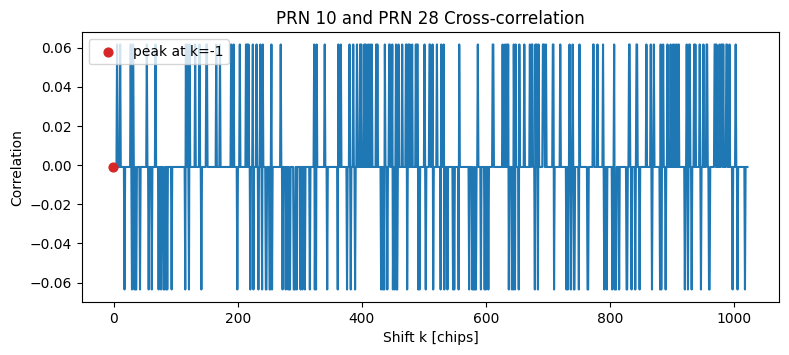

P3.4
Peak: -1
Number of unique values: 3
Unique values:   [-0.0635 -0.000978 0.0616]
Expected values: [-0.0635 -0.000978 0.0616]


In [36]:
prn_10 = 2 * create_prn(2,3,1023) - 1 # Satellite 10
prn_28 = 2 * create_prn(8,10,1023) - 1 # Satellite 10
r = correlate(prn_10, prn_28)

N = len(prn)
k = np.arange(0,N)

unique_values = np.unique(r)  # TODO
peak = int(np.argmax(r)) if r.max() > 0.5 else -1

# Expected values from book 9.5.2 (for cross-correlations)
n_exponent = np.log2(N + 1)
beta = 1 + 2**( np.floor((n_exponent+2)/2) )
expected_values = np.sort(np.round(
    np.array([-1.0/N, (beta-2)/N, -beta/N]),
    6
))

k = np.arange(N)
plt.figure(figsize=(9, 3.5))
plt.plot(k, r)
plt.scatter([peak], [r[peak]], s=40, color="tab:red", zorder=3, label=f"peak at k={peak}") # Peak
plt.title("PRN 10 and PRN 28 Cross-correlation")
plt.xlabel("Shift k [chips]")
plt.ylabel("Correlation")
plt.legend(loc="best")
plt.show()

# *** DO NOT MODIFY THE CODE BELOW ***
print("P3.4")
print("Peak:", peak)
print("Number of unique values:", len(unique_values))
with np.printoptions(formatter={"float": lambda x: f"{x:0.3g}"}):
    print("Unique values:  ", unique_values)
    print("Expected values:", expected_values)

Because the two signals' gold codes are different, the cross correlation of two different PRNs is expected to not align, which it does not. Rather than having a high peak of 1 at some chip shift, it does not go higher than about 0.06 in both directions.

### 3.5 Composite Signal [2 points]

Now, we have all the pieces to discover the power of CDMA. Let's assess if we can pick out the signal of interest (from PRN 10) from a cluttered signal environment. Create the following three 1023-length PRNs:

1. $x_1$ as PRN 10 delayed by 200 chips.

2. $x_2$ as PRN 28 delayed by 150 chips.

3. $x_3$ as PRN 32 delayed by 300 chips.

Sum these 3 signals together via element-wise addition: $x(n) = x_1(n) + x_2(n) + x_3(n)$. This is our composite signal, mimicking reception from all three satellites that are visible in the sky. Correlate the composite signal $x$ with a replica of PRN 10. Is the peak of the correlation where you had expected it to be? Explain why or why not.

From the lectures, you may recall that the GPS signal is quite weak. Let's see if CDMA can pick out the GPS PRN code even in the presence of radio frequency noise.

***ANSWER***

[Compute and plot the cross-correlation, provide its peak (if present), and explain whether the results are expected.]

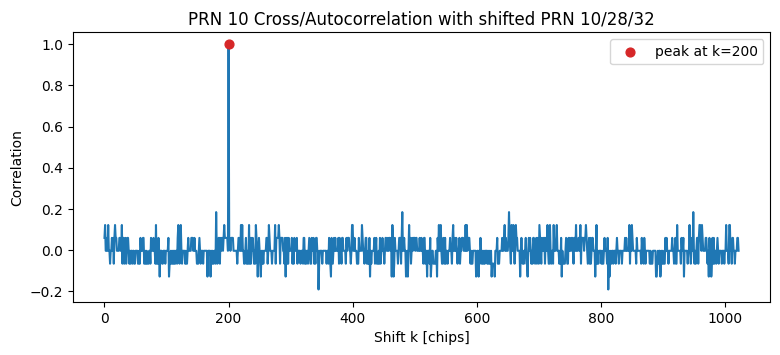

P3.5
Peak: 200
First 10 samples: [ 0.05962854  0.12218964 -0.00293255 -0.00293255  0.05962854 -0.00293255
  0.12218964 -0.00293255 -0.00293255 -0.06549365]


FileNotFoundError: [Errno 2] No such file or directory: 'autograder/solutions/Sol_35.txt'

In [37]:
prn_shift = lambda s1,s2,shift: np.roll(2 * create_prn(s1,s2,1023) - 1, shift)

prn_10 = prn_shift(2, 3, 0) # PRN 10
x1 = prn_shift(2, 3, 200) # PRN 10 delayed by 200 chips.
x2 = prn_shift(8, 10, 150) # PRN 28 delayed by 150 chips.
x3 = prn_shift(4, 9, 300) # PRN 32 delayed by 300 chips.
x_sum = x1 + x2 + x3

r = correlate(x_sum, prn_10)
first_10_samples = r[:10]  # TODO
peak = int(np.argmax(r)) if r.max() > 0.5 else -1

N = len(prn)
k = np.arange(N)
plt.figure(figsize=(9, 3.5))
plt.plot(k, r)
plt.scatter([peak], [r[peak]], s=40, color="tab:red", zorder=3, label=f"peak at k={peak}") # Peak
plt.title("PRN 10 Cross/Autocorrelation with shifted PRN 10/28/32")
plt.xlabel("Shift k [chips]")
plt.ylabel("Correlation")
plt.legend(loc="best")
plt.show()

# *** DO NOT MODIFY THE CODE BELOW ***
print("P3.5")
print("Peak:", peak)
print("First 10 samples:", first_10_samples)

# Autograder
with open("autograder/solutions/Sol_35.txt", "w") as f:
    f.writelines([str(peak), "\n", str(first_10_samples)])

This plot is a combination of several of the previous ones. First, that differing PRN numbers will not have a cross-correlation that is 1 (or near 1). Second, that a delayed signal of the same cross-correlation will have a peak at that chip offset. Because we are trying to cross-correlate a signal with PRN 28 and PRN 32, those do not produce any peak at their offsets of 150 and 300 respectively. But auto-correlating with PRN 10 at 200 chips offset produces a peak at 200 chips, as expected. This shows how the correlation function is able to recover the signal from one satellite out of many.

### 3.6 Adding Noise [2 points]

In order to simulate the effect of radio frequency noise on signal tracking of a C/A code, create a 1023-element vector with noise $\eta$, each element of which is independent and identically distributed as a zero-mean Gaussian with a standard deviation of 4. Add this vector of noises to the composite signal from 5. Plot this noisy composite signal and the code for PRN 10 in the same plot to get an idea of the relative amplitude difference (include a legend to distinguish the two lines). Plot for the full 1023-element sequence.


[Compute and plot the code for PRN 10, the composite signal, and the noise.]

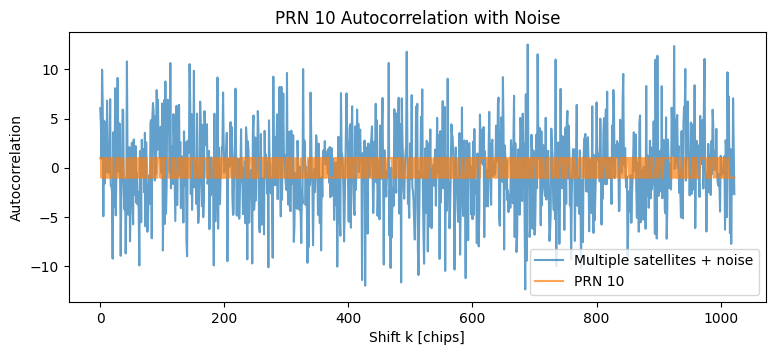

In [38]:
np.random.seed(0)
sd = 4
n = 1023
noise = np.random.normal(scale=sd, size=n)
composite = noise + x_sum

N = len(prn)
k = np.arange(N)
plt.figure(figsize=(9, 3.5))
plt.plot(k, composite, alpha=0.7, label="Multiple satellites + noise")
plt.plot(k, prn_10, alpha=0.7, label="PRN 10")
# plt.scatter([peak], [r[peak]], s=40, color="tab:red", zorder=3, label=f"peak at k={peak}") # Peak
plt.title("PRN 10 Autocorrelation with Noise")
plt.xlabel("Shift k [chips]")
plt.ylabel("Autocorrelation")
plt.legend(loc="best")
plt.show()

This demonstrates the strength of the correlation function. The signals from the GPS are much smaller than noise, but can still be diffrentiated.

### 3.7 Removing Noise [3 points]

Now, correlate the noisy composite signal from 6 with a replica of PRN 10 and plot the resulting correlation. Is the peak where you would expect it to be? Are you surprised by the ability of PRN 10 to survive the interference from noise and the other PRNs? Explain why or why not.

[Compute and plot the cross-correlation, provide its peak (if present), and explain whether the results are expected.]

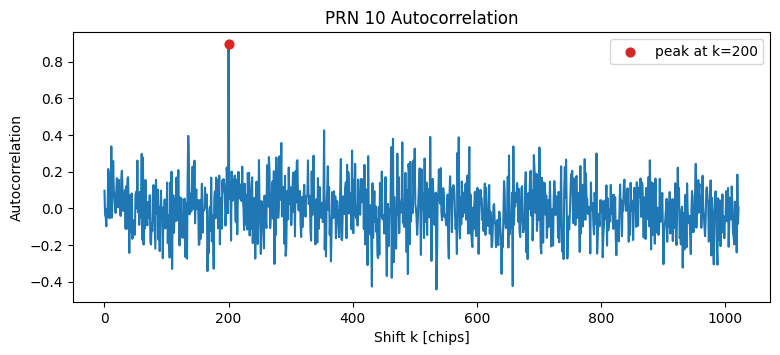

P3.7
Peak: 200


In [39]:
r = correlate(composite, prn_10)
peak = int(np.argmax(r)) if r.max() > 0.5 else -1

N = len(prn)
k = np.arange(N)
plt.figure(figsize=(9, 3.5))
plt.plot(k, r)
plt.scatter([peak], [r[peak]], s=40, color="tab:red", zorder=3, label=f"peak at k={peak}") # Peak
plt.title("PRN 10 Autocorrelation")
plt.xlabel("Shift k [chips]")
plt.ylabel("Autocorrelation")
plt.legend(loc="best")
plt.show()

print("P3.7")
print("Peak:", peak)

Unsurprisingly, the 200-chip offset PRN 10 produces a peak at 200 chips, despite how prevalent the noise is. This makes sense because even though the noise is much greater, they are just random noise without a gold code that PRN 10 has.

### Bonus 1 [1 point]

To further demonstrate the power of cross-correlation, let's assume that we are now dealing with a noise standard deviation of 20. Since the PRN codes are periodic, we can treat each period separately. For three different noise realizations, repeat 3.7 and plot the three cross-correlations.

- Are you able to differentiate the peak from the noise? Is the peak where we expect it to be?

Since the noise is typically not correlated over time (this might not always be the case), we can average the cross-correlations obtained during consecutive PRN code periods:
$$
R_N[k] = \frac{1}{N}\sum_{i=0}^{N-1} r_{xy}^{(i)}[k]
$$
where $N$ is the number of periods we are considering and $r_{xy}^{(i)}$ is the cross-correlation for the $i$-th period.

- Plot the cross-correlations for an increasing number of considered periods.

- How many sequences do we need to average before the peak is where we expect it to be? How much time would a user have to wait?

- At what rate does the standard deviation of the noise floor decrease as we increase the number of averaged sequences $N$?